In [5]:
import os
import json
import textwrap
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

def list_subdirectories(flux_dir):
    return [
        name for name in os.listdir(flux_dir)
        if os.path.isdir(os.path.join(flux_dir, name)) and 'logs' not in name
    ]


In [99]:
filtered_flux_results_path = '/data3/jhpark/filtered_data_synth/coco/animal'
filtered_flux_results_dirs = list_subdirectories(filtered_flux_results_path)
flux_results_iter = iter(filtered_flux_results_dirs)

In [113]:
def plot_explanations(parent_dir, subdirectory):
    metadata_path = os.path.join(parent_dir, subdirectory, "metadata.json")
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    print(metadata)
    real_image_path = os.path.join(parent_dir, subdirectory, "real_image.png")
    real_img = mpimg.imread(real_image_path)
    artifact_image_path = os.path.join(parent_dir, subdirectory, "artifact_image.png")
    img = mpimg.imread(artifact_image_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')

    for idx, artifact in enumerate(metadata['artifacts']):
        bbox = artifact['target_bbox']
        x1, y1, x2, y2 = bbox
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)
        # plt.gca().text(x1, y1 - 5, str(idx) +' ' + artifact['artifact_type'], color='white', fontsize=12, weight='bold', va='bottom', ha='left', bbox=dict(facecolor='r', alpha=0.5, edgecolor='none', pad=1))
        if artifact['artifact_type'] == 'distortion':
            label_text = str(idx) + ' ' + artifact.get('distortion_kernel', 'distortion')
        else:
            label_text = str(idx) + ' ' + artifact['artifact_type']
        plt.gca().text(
            x1, y1 - 5, label_text,
            color='white', fontsize=12, weight='bold', va='bottom', ha='left',
            bbox=dict(facecolor='r', alpha=0.5, edgecolor='none', pad=1)
        )
        print('\n'.join(textwrap.wrap(artifact['explanation'], width=80)))
        print('--------------------------------')
    print(metadata['caption'])
    plt.show()
    plt.close()

    from IPython.display import display
    from PIL import Image

    display(Image.open(real_image_path))
    display(Image.open(artifact_image_path))


{'artifacts': [{'target_bbox': [352, 96, 544, 400], 'artifact_type': 'fusion', 'entity': 'horse', 'artifact_entity': 'person', 'explanation': "The horse and the person are blended together, with the horse's body appearing to merge into the person's legs. The textures and colors are mixed, and the boundary between them is lost.", 'label': 'Horse and person merged together.'}, {'target_bbox': [96, 128, 176, 288], 'artifact_type': 'addition', 'entity': 'horse', 'artifact_entity': 'tail', 'explanation': 'The horse has two tails instead of one, which is not natural. The extra tail is placed next to the original, creating an unrealistic appearance.', 'label': 'The horse has an extra tail.'}], 'caption': "The image shows a horse with an unusual blending of its body into a person's legs, creating a confusing and merged appearance where the textures and colors of both are mixed. Additionally, the horse has two tails, which is not typical, adding to the overall unnatural look of the scene."}
The

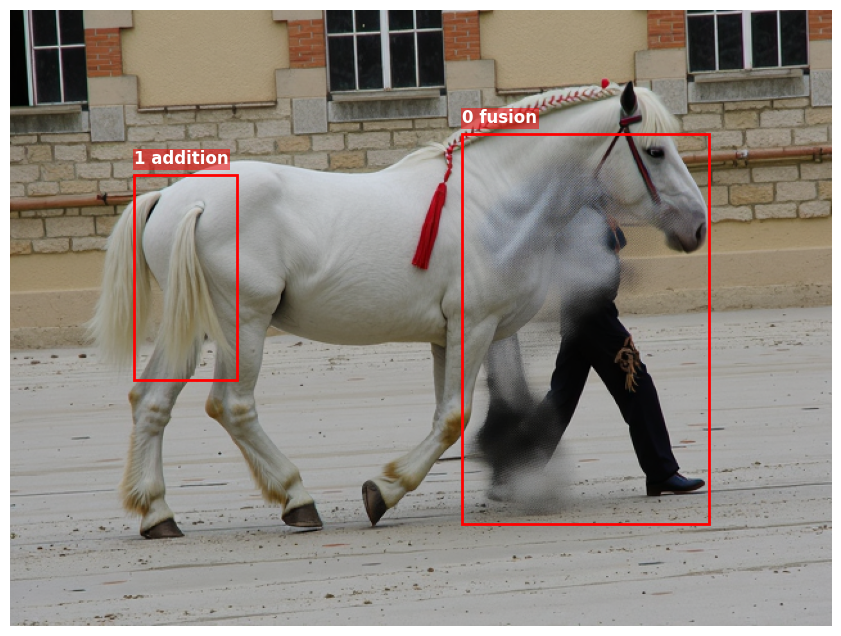

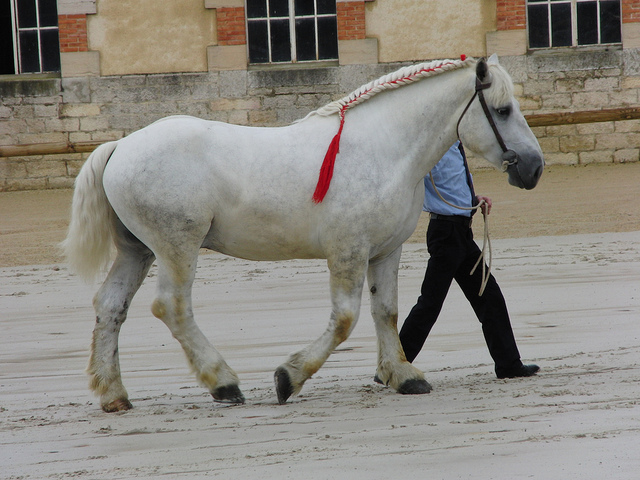

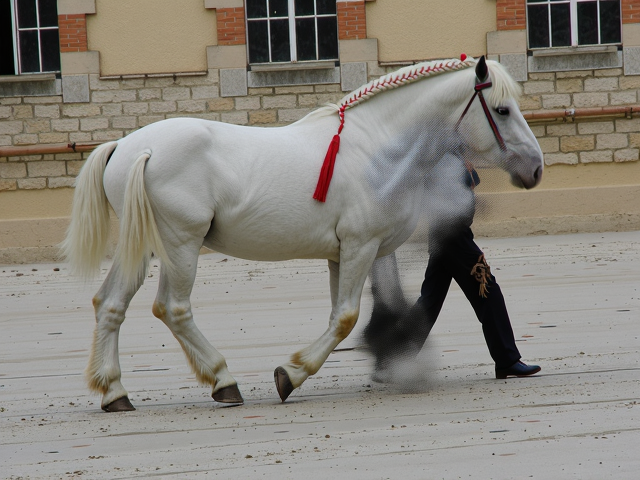

In [367]:
flux_result = next(flux_results_iter)

plot_explanations(filtered_flux_results_path, flux_result)